#### Emergency Medicine Triage RAG System

This notebook implements a complete Retrieval-Augmented Generation (RAG) system for emergency medicine triage decision support. The system processes new patient cases by:
1. Analyzing the case description
2. Finding similar past cases
4. Generating a comprehensive triage assessment

****RAG implementation with similar Past Cases only**

In [1]:
import json
import re
from typing import List, Dict, Any, Optional, Tuple, TypedDict, Literal
import os
from dotenv import load_dotenv
from tqdm import tqdm
from tqdm.notebook import tqdm
import traceback

# LangChain imports
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
from langchain_openai import AzureOpenAIEmbeddings
from langchain_community.vectorstores import Chroma

# Pydantic imports
from pydantic import BaseModel, Field, ValidationError

# LangGraph imports
from langgraph.graph import StateGraph, END

## System Architecture Overview

This notebook implements a multi-stage RAG pipeline using a graph-based architecture. The key components are:

1. **Data Sources**:
   - Triage guidelines structured in sections
   - Past emergency cases with known triage outcomes
   - Vector embeddings of past cases for similarity search

2. **LLM setup**:
   - **LLM Initialization**(choose one): Used to generate clinical summaries and reasoning task
        1. **DeepSeek-v3** (updated to deepseek-v4-pro)
        2. **gpt-4o**
        3. **claude-3-7-sonnet**
   - Setting up Azure OpenAI embeddings for vector search

3. **Pipeline Flow**:
   - Case preprocessing and summarization
   - Specialty prediction
   - Similar case retrieval
   - Integrated final assessment
   
Each component is implemented as a node in a LangGraph that manages state transitions through the pipeline.

## Step 1: Initial Setup and Configuration

This section initializes all required components:

1. **Environment Configuration**:
   - Loading API keys and endpoints from environment variables
   
2. **LLM setup**:
   - **LLM Initialization**(choose one): Used to generate clinical summaries and reasoning task
        1. **DeepSeek-v3** (updated to deepseek-v4-pro)
        2. **gpt-4o**
        3. **claude-3-7-sonnet**
   - Setting up Azure OpenAI embeddings for vector search

3. **Data Loading**:
   - Triage guidelines with section summaries
   - Vector database of past cases
   - Specialty mapping for case categorization
   
4. **State Definition**:
   - Defining the `GraphState` class to track data through the pipeline
   - Managing transitions between processing stages

In [2]:
# Load environment variables
load_dotenv()

# Verify environment variables
required_env_vars = [
    "AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT_NAME",
    "AZURE_OPENAI_ENDPOINT",
    "AZURE_OPENAI_API_KEY",
    "AZURE_OPENAI_API_VERSION",
    "DEEPSEEK_API_KEY",
]

missing_vars = [var for var in required_env_vars if not os.getenv(var)]
if missing_vars:
    raise ValueError(f"Missing environment variables: {', '.join(missing_vars)}")

print("Environment variables loaded successfully.")

Environment variables loaded successfully.


In [3]:
from langchain_deepseek import ChatDeepSeek

llm = ChatDeepSeek(
    model="deepseek-v4-pro",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    temperature=0,
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)
print("LLM initialized successfully.")

model = "deepseek-v4-pro"

LLM initialized successfully.


In [4]:
# from langchain_openai import AzureChatOpenAI


# def initialize_azure_openai(
#     azure_deployment_name: str = os.getenv("AZURE_OPENAI_LLM_DEPLOYMENT_NAME"),
#     azure_endpoint: str = os.getenv("AZURE_OPENAI_ENDPOINT"),
#     azure_api_key: str = os.getenv("AZURE_OPENAI_API_KEY"),
#     azure_api_version: str = os.getenv("AZURE_OPENAI_API_VERSION"),
#     temperature: float = 0
# ):
#     """
#     Initialize Azure OpenAI client
    
#     Args:
#         azure_deployment_name (str): Azure deployment name
#         azure_endpoint (str): Azure endpoint URL
#         azure_api_key (str): Azure API key
#         azure_api_version (str): Azure API version
#         temperature (float): Temperature for generation
        
#     Returns:
#         AzureChatOpenAI: Initialized Azure OpenAI client
#     """
#     return AzureChatOpenAI(
#         azure_deployment=azure_deployment_name,
#         azure_endpoint=azure_endpoint,
#         api_key=azure_api_key,
#         api_version=azure_api_version,
#         temperature=temperature
#     )


# llm = initialize_azure_openai()

# print("LLM initialized successfully.")

# model = "gpt-4o"

In [5]:
# from langchain_anthropic import ChatAnthropic

# def initialize_claude(
#     api_key: str = os.getenv("ANTHROPIC_API_KEY"),
#     model_name: str = os.getenv("ANTHROPIC_MODEL_NAME"),
#     temperature: float = 0,
#     max_tokens: int = 8192,  
#     streaming: bool = True
# ):
#     """
#     Initialize Claude client using LangChain
    
#     Args:
#         api_key (str): Anthropic API key
#         model_name (str): Model name to use (claude-3-7-sonnet-20250219 for latest Claude 3.7 Sonnet)
#         temperature (float): Temperature for generation
        
#     Returns:
#         ChatAnthropic: Initialized Claude client
#     """
#     return ChatAnthropic(
#         model=model_name,
#         anthropic_api_key=api_key,
#         temperature=temperature,
#         max_tokens=max_tokens,
#         streaming=streaming
#     )

# llm = initialize_claude()

# print("Claude LLM initialized successfully.")

# model = "claude-3-7"

In [6]:
def initialize_embeddings() -> AzureOpenAIEmbeddings:
    """Initialize Azure OpenAI embeddings"""
    return AzureOpenAIEmbeddings(
        azure_deployment=os.getenv("AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT_NAME"),
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        api_key=os.getenv("AZURE_OPENAI_API_KEY"),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    )

# Initialize embeddings
embeddings = initialize_embeddings()
print("Embeddings initialized successfully.")

Embeddings initialized successfully.


In [7]:
# Load the Vector DB (Past Cases)

# Constants and configurations
BASE_DIR = f"../../db/past_case/case_vectordb_{model}_3000case"

# Load existing vector databases
def load_vector_databases(base_dir: str) -> Chroma:
    """
    Load existing Chroma vector databases
    
    Args:
        base_dir: Base directory containing the vector databases
        
    Returns:
        Chroma VectorDB
    """
    summary_vectordb = Chroma(
        persist_directory=os.path.join(base_dir, "summary_vectordb"),
        embedding_function=embeddings,
        collection_name="summary_text"
    )
    
    return summary_vectordb

# Load vector database
summary_vectordb = load_vector_databases(BASE_DIR)

# Print a sample of IDs
print(f"Summary DB: {summary_vectordb.get()['ids'][:3]}...")

# Print the number of documents in each database
print(f"Summary DB document count: {summary_vectordb._collection.count()}")
print("Vector databases loaded successfully.")

# set past case full json dir 
case_json_dir = os.path.join(BASE_DIR, "json_store")
print(f"Past Case Json Store dir: {case_json_dir}")

k_cases = 5
print(f"will retrieve top-{k_cases} past-cases for each case")

C:\Users\Thomas Wong\AppData\Local\Temp\ipykernel_18232\2583557833.py:17: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  summary_vectordb = Chroma(


Summary DB: ['ae24f8e7-9b83-4291-845d-097c7f9bd2e0', 'f926e349-1080-4dbf-a960-5ab12095f5d1', 'e8a3d973-a5ed-4a19-9e3f-90b161e4210f']...
Summary DB document count: 2881
Vector databases loaded successfully.
Past Case Json Store dir: ../../db/past_case/case_vectordb_deepseek-v4-pro_3000case\json_store
will retrieve top-5 past-cases for each case


In [8]:
# Load unique "Attending Specialty" values directly from vector database metadata
all_metadatas = summary_vectordb.get()["metadatas"]
unique_specialties = list({
    m["Attending Specialty"]
    for m in all_metadatas
    if "Attending Specialty" in m and m["Attending Specialty"]
})
print(unique_specialties)

['O & T', 'Dental', 'NS', 'Others: Oncology', 'Surg', 'ENT', 'Gynae', 'Derma', 'Others: URO', 'Others: UROLOGY', 'IDU', 'Others: ONCO', 'Eye', 'Burn', 'Paed', 'Others: ONC', 'RT', 'Orthopaedics', 'Others: oncology', 'Others', 'CTS', 'Obs/Mat', 'Medicine', 'Psych']


In [9]:
# Perform Mapping (Manual Mapping depending on the above cell output)
AGENT_SPECIALTY_LIST = [
    'Medicine', 'Surgery', 'Obstetrics and Gynaecology', 'Oncology', 'Neurosurgery', 'Orthopaedics', 'Paediatrics', 
    'Eye', 'Psychiatry','ENT', 'Dermatology', 'Dental', 'Others'
]

# Mapping from standardized names to the actual values in the dataset
SPECIALTY_MAPPING = {
    "Medicine": ["Medicine", "IDU"],
    "Surgery": ["Surg", "Surgery", "Burn", "Others: UROLOGY", "Others: URO", "CTS"],
    "Obstetrics and Gynaecology": ["Gynae", "Obs/Mat"],
    "Oncology": ["Others: Onco", "Others: Oncology", "Others: onco", "Others: oncology", "RT", "Others: ONCO", "Others: ONC"],
    "Neurosurgery": ["NS"],
    "Orthopaedics": ["O & T", "Orthopaedics"],
    "Paediatrics": ["Paed"],
    "Eye": ["Eye"],
    "Psychiatry": ["Psych"],
    "ENT": ["ENT"],
    "Dermatology": ["Derma"],
    'Dental': ["Dental"],
    "Others": ["Others"] 
}

# Reverse mapping for lookup (actual values -> standardized names)
REVERSE_SPECIALTY_MAPPING = {}
for standard, variations in SPECIALTY_MAPPING.items():
    for variation in variations:
        REVERSE_SPECIALTY_MAPPING[variation] = standard
        

def map_specialty_to_dataset_values(specialty: str) -> List[str]:
    """
    Map a standardized specialty name to all its variations in the dataset
    
    Args:
        specialty: Standardized specialty name
        
    Returns:
        List of corresponding values in the dataset
    """
    if not specialty:
        return []
    
    return SPECIALTY_MAPPING.get(specialty, [])

def get_standardized_specialty(dataset_value: str) -> str:
    """
    Map a value from the dataset to its standardized specialty name
    
    Args:
        dataset_value: Value from the dataset
        
    Returns:
        Standardized specialty name
    """
    return REVERSE_SPECIALTY_MAPPING.get(dataset_value, "Others")

In [10]:
def create_specialty_prediction_schema(specialty_list: List[str]):
    """Dynamically create SpecialtyPredictionOutput using the provided specialty list."""
    SpecialtyLiteral = Literal[tuple(specialty_list)]

    class SpecialtyPredictionOutput(BaseModel):
        """Structured output for specialty prediction"""
        specialties: List[SpecialtyLiteral] = Field(
            description=(
                "Ordered list of attending specialties: 1 specialty if one clearly covers the case, "
                "2 specialties (primary first) if there is genuine overlap"
            ),
            min_items=1,
            max_items=2,
        )
        explanation: str = Field(description="Brief explanation of specialty selection (1-2 sentences)")

    return SpecialtyPredictionOutput

In [11]:
# Define state structure
class GraphState(dict):
    """State for the retrieval graph."""
    summary_text: Optional[str] = None                                          # embedding for vector search of past case retrieval
    metadata_filter: Dict[str, Any]                                             # filter for past case retrieval
    case_json_full: Dict[str, Any]                                              # full case json
    specialty_list: List[str]                                                   # standardized specialty list
    selected_attending_specialty: Optional[Dict[str, Any]] = None              # selected specialty
    retrieved_cases: List[Dict[str, Any]] = []                                  # retrieved cases
    retrieved_cases_content: List[Dict[str, Any]] = []
    past_cases_context: str = ""
    final_assessment: Optional[str] = None
    final_category: Optional[str] = None                                        # final triage category
    final_confidence: Optional[str] = None                                      # final confidence level
    processing_failed: Optional[bool] = False                                   # whether processing failed
    failure_reason: Optional[str] = None                                        # reason for failure
    failed_node: Optional[str] = None                                           # node where failure occurred

In [12]:
class TriageStep(BaseModel):
    category: Literal["1", "2", "3", "4", "5", "Not specified"] = Field(description="Triage category")
    confidence: Literal["High", "Medium", "Low"] = Field(description="Confidence level")
    reason: str = Field(description="Reasoning for this step")

class TriagePredictionOutput(BaseModel):
    """2-step variant — step1 clinical risk + step2 real-world factors (past cases only, no guidelines)"""
    step1_clinical_risk: TriageStep = Field(description="Clinical risk assessment")
    step2_realworld_factors: TriageStep = Field(description="Real-world factors adjustment based on past cases")
    final_decision: TriageStep = Field(description="Final triage decision")

class TokenUsageMetrics(BaseModel):
    prompt_tokens: int = 0
    completion_tokens: int = 0
    total_tokens: int = 0

def get_token_usage(response) -> TokenUsageMetrics:
    try:
        if hasattr(response, 'response_metadata') and 'token_usage' in response.response_metadata:
            usage = response.response_metadata['token_usage']
            return TokenUsageMetrics(
                prompt_tokens=usage.get('prompt_tokens', 0),
                completion_tokens=usage.get('completion_tokens', 0),
                total_tokens=usage.get('total_tokens', 0),
            )
    except Exception as e:
        print(f"Could not extract token usage: {e}")
    return TokenUsageMetrics()

def execute_structured_node_with_retry(node_func, state, node_name, max_retries=3):
    """
    Execute a node with retry logic for malformed structured responses.
    Returns failed_state on exhausted retries — use only for terminal nodes.
    """
    for attempt in range(1, max_retries + 1):
        try:
            return node_func(state)
        except ValidationError as e:
            print(f"[{node_name}] ValidationError on attempt {attempt}/{max_retries}: {e}")
            if attempt == max_retries:
                print(f"{node_name} FAILED after {max_retries} retries")
                failed_state = state.copy()
                failed_state["processing_failed"] = True
                failed_state["failure_reason"] = f"{node_name} failed after {max_retries} retries: {str(e)}"
                failed_state["failed_node"] = node_name
                return failed_state
        except Exception as e:
            print(f"[{node_name}] Error on attempt {attempt}/{max_retries}: {type(e).__name__}: {e}")
            if attempt == max_retries - 1:
                failed_state = state.copy()
                failed_state["processing_failed"] = True
                failed_state["failure_reason"] = f"{node_name} failed with unexpected error: {str(e)}"
                failed_state["failed_node"] = node_name
                return failed_state

## Step 2: Utility Functions

These utility functions handle data processing tasks throughout the pipeline:

1. **Case Loading**:
   - Functions to load and preprocess case JSON files
   
2. **Metadata Filtering**:
   - Functions to filter vector database results by metadata
   - Enables more targeted retrieval of similar past cases

In [13]:
# Initial loading of JSON file (new case)
def load_case_from_json(file_path: str) -> Dict[str, Any]:
    """
    Load a FULL case from a JSON file as NEW case. 

    Args:
        file_path (str): Path to the JSON file

    Returns:
        Dict[str, Any]: FULL Case data, with "Case Disposition" removed(required for test/val set).
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        case_data = json.load(f)

    # Remove sections if it exists, required for ground_truth set 
    if "Case Disposition" in case_data:
        case_data.pop("Case Disposition")
    if "Ground Truth" in case_data:
        case_data.pop("Ground Truth")

    return case_data

In [14]:
# filtering past case in vectordb according to metadata filters
def filter_documents_by_metadata(
    vectordb: Chroma, 
    metadata_filters: Dict[str, Any],
    threshold: float = 1.0
) -> List[str]:
    """
    Filter documents by metadata criteria and return doc_ids that meet the criteria
    
    Args:
        vectordb: The vector database to search in
        metadata_filters: Dictionary of metadata filters to apply
        threshold: Minimum fraction of filters that must match (0.0-1.0)
        
    Returns:
        List of document IDs that match the metadata criteria
    """
    # Get all documents
    all_docs = vectordb.get()
    all_metadatas = all_docs["metadatas"]
    doc_ids = all_docs["ids"]
    
    matching_ids = []
    
    for i, metadata in enumerate(all_metadatas):
        # Count how many filters match
        match_count = 0
        total_applicable_filters = 0
        
        for key, value in metadata_filters.items():
            # Skip if the filter key doesn't exist in this document's metadata
            if key not in metadata:
                continue
                
            total_applicable_filters += 1
            
            # Check if values match (case-insensitive for string values)
            if isinstance(metadata[key], str) and isinstance(value, str):
                if metadata[key].lower() == value.lower():
                    match_count += 1
                    # print(f"Matched {key}: {metadata[key]} with {value}")
            else:
                if metadata[key] == value:
                    match_count += 1
                    # print(f"Matched {key}: {metadata[key]} with {value}")
        
        # Only include if at least threshold percentage of filters match
        if total_applicable_filters > 0 and (match_count / total_applicable_filters) >= threshold:
            matching_ids.append(doc_ids[i])
    
    return matching_ids

## RAG Pipeline Implementation

The following sections implement the core RAG pipeline using a modular node-based approach. Each node performs a specific function and passes its results to subsequent nodes through the shared state object.

## Step 3: Node Definitions

Each node in the LangGraph represents a discrete processing step in the RAG pipeline. These nodes transform the input state and pass the results to downstream nodes.

### Core Pipeline Components

The pipeline consists of three main stages:
1. **Preprocessing**: Analyzing and summarizing the input case
2. **Retrieval**: Finding relevant guidelines and similar past cases 
3. **Generation**: Producing the final triage assessment

### 3.1: Preprocessing Node
The preprocessing node converts the raw case data into a concise clinical summary that captures the most relevant medical information. This summary serves as the query for both guideline retrieval and case similarity search, ensuring that retrieval focuses on clinically significant elements.

In [15]:
# Define node to preprocess case data
def process_case_summary(state: GraphState) -> GraphState:
    
    ## Create Summary for VectorDB retrieval 
    
    sections_to_expand = {}
    
    sections_for_summary = {}
    if 'Demographics' in state["case_json_full"]:
        if 'Age' in state["case_json_full"]['Demographics']:
            sections_for_summary['Age'] = state["case_json_full"].get("Demographics", {}).get("Age", "")
        if 'Sex' in state["case_json_full"]['Demographics']:
            sections_for_summary['Sex'] = state["case_json_full"].get("Demographics", {}).get("Sex", "")
    if 'Vitals and Observations' in state["case_json_full"]:
        sections_for_summary['Vitals and Observations'] = state["case_json_full"].get("Vitals and Observations", {})
    if "Clinical Presentation" in state["case_json_full"]:
        sections_for_summary['Clinical Presentation'] = state["case_json_full"].get("Clinical Presentation", {})
        
    summary_prompt = ChatPromptTemplate.from_messages([
        ("system", """
        You are a specialized medical summarization assistant for emergency triage notes. Your task is to analyze structured JSON data from triage notes and create a concise, retrievable summary highlighting only the most important clinical information.
        ## INPUT STRUCTURE
        You will receive structured JSON data containing:
        - Demographics (sex, age)
        - Clinical Presentation (chief complaint, condition on arrival)
        - Vitals and Observations

        ## OUTPUT REQUIREMENTS
        1. Generate a concise (2-3 sentence) summary focusing on:
           - Patient demographics (sex, age)
           - Key presenting complaints
           - Abnormal physical findings
           - ONLY abnormal vital signs according to strict criteria

        2. Write in a factual, medical style optimized for vector embedding retrieval.

        ## MEDICAL TERMINOLOGY GUIDELINES
        - Interpret medical abbreviations contextually 
        - Fix obvious typos/misspellings based on medical context
        - Maintain medical precision while expanding clarity
        - For Hong Kong hospital/facility abbreviations:
          - "PMH" → "Princess Margaret Hospital"
          - "KCH" → "Kwai Chung Hospital"
          - "OAH" → "Old Age Home"
          - If uncertain about any abbreviation, do NOT expand it

        ## VITAL SIGNS ABNORMALITY CRITERIA
        ONLY mention vital signs that meet these specific abnormality thresholds:

        - Blood Pressure (Adult):
          - Hypertension: SBP > 180 mmHg or DBP > 100 mmHg
          - Hypotension: SBP < 90 mmHg

        - Heart Rate (Adults):
          - Tachycardia: HR > 120/min
          - Bradycardia: HR < 50/min

        - Temperature (Adult):
          - Fever: Temp ≥ 38°C
          - Hypothermia: Temp < 35°C

        - Blood Sugar:
          - Hyperglycemia: H'stix > 16 mmol/l
          - Hypoglycemia: H'stix < 3.9 mmol/l

        - Respiratory Status (always consider):
          - Oxygen supplementation (if present)
          - SpO2 level if abnormal
          - Abnormal respiratory rate

        - Conscious Level:
          - GCS score if not 15/15
          - Pupil abnormalities (if provided)

        - Pregnancy/Menstruation: Note if pregnant or abnormal menstrual patterns

        ## EXAMPLES OF GOOD SUMMARIES:

        ### Example 1:
        Input: [
            {{
                "Demographics": {{
                    "Sex": "F",
                    "Age": "56 years"
                }},
                "Clinical Presentation": {{
                    "Chief complaint": "R/F ? IHD, tachycardia oedema\\nSOB , LL edema and neck swelling x 10/7 \\nchest discomfort - , palpitiation",
                    "Condition on Arrival": "speak in sentence"
                }},
                "Vitals and Observations": {{
                    "Vital Signs": {{
                        "GCS": "E: 4, V: 5, M: 6, Score: 15/15",
                        "BP": "1st: 144/89 mmHg",
                        "PR/AR": "99",
                        "Temp": "36.2",
                        "SpO2": "100% on room air, --",
                        "RR": "--",
                        "PFR": "--",
                        "Limbs": "--",
                        "Pupil": "--"
                    }},
                    "Triage Intervention": {{
                        "H'stix": "",
                        "H'cue": ""
                    }},
                    "Menstruation / Pregnancy Status": "unspecified"
                }}
            }}
        ]
        
        Output: "56-year-old female presenting with shortness of breath, lower limb edema, and neck swelling for 10 days, accompanied by chest discomfort and palpitations. Patient can speak in full sentences and has been referred for evaluation of possible ischemic heart disease with tachycardia and edema. All vital signs are within normal ranges."

        ### Example 2:
        Input: [
            {{
                "Demographics": {{
                    "Sex": "M",
                    "Age": "64 years"
                }},
                "Clinical Presentation": {{
                    "Chief complaint": "SOB this morning 0730\\nroom air 70%",
                    "Condition on Arrival": "no lower limb oedema\\nsputum sound+/-"
                }},    
                "Vitals and Observations": {{
                    "Vital Signs": {{
                        "GCS": "",
                        "BP": "1st: 165/97 mmHg",
                        "PR/AR": "130",
                        "Temp": "38.1",
                        "SpO2": "96% on 6 L/min via Nasal Cannula",
                        "RR": "20",
                        "PFR": "--",
                        "Limbs": "--",
                        "Pupil": "--"
                    }},
                    "Triage Intervention": {{
                        "H'stix": "",
                        "H'cue": ""
                    }}
                }}
            }}
        ]
        Output: "64-year-old male presenting with sudden onset shortness of breath at 7:30 AM with significant hypoxia (70% on room air). Patient has tachycardia (HR 130), fever (38.1°C), and requires oxygen supplementation (6 L/min via Nasal Cannula). Clinical examination reveals sputum sounds without lower limb edema."

        ## IMPORTANT REMINDERS:
        - Focus on clinical relevance and retrieval effectiveness
        - Maintain medical accuracy while being concise
        - Only highlight abnormal vitals based on specific thresholds
        - Fix obvious errors but maintain meaning integrity
        - Adjust abnormality thresholds for pediatric cases
        """),
        ("user", """
        Case Data (JSON):
        {case_data}

        OUTPUT (Summary):
        """)
    ])
        
    # Prepare the input for the prompt
    case_data_str = json.dumps(sections_for_summary, indent=2)
    input_values = {
        "case_data": case_data_str
    }
    # Get the LLM response
    chain = summary_prompt | llm | StrOutputParser()
    response = chain.invoke(input_values)
    
    updated_state = state.copy()
    updated_state["summary_text"] = response
    return updated_state

### 3.2 Retrieval Nodes

The retrieval nodes perform three key functions:
1. **Specialty prediction**: Determining which medical specialty would typically handle this case
2. **Similar case retrieval**: Finding past cases with similar clinical presentations and contexts

These retrieval components combine rule-based and similarity-based approaches to provide comprehensive context for the final assessment.

In [16]:
def attending_specialty_decision(state: GraphState) -> GraphState:
    """
    Predict attending specialty with native structured output.
    Returns 1-2 specialties as an ordered list (primary first).
    """
    summary_text = state["summary_text"]
    specialty_list = state["specialty_list"]

    SpecialtyPredictionOutput = create_specialty_prediction_schema(specialty_list)

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an emergency-medicine specialist assistant that helps determine the most appropriate attending specialty for presenting cases.
Given a medical case summary, determine the attending specialty.

You must select specialties from the following list only:

{specialty_list}

Return 1 specialty if one specialty clearly covers the case.
Return 2 specialties (primary first) if there is genuine overlap, for example:
   - Injury-related cases could be covered by "Surgery", "Orthopaedics" or "Neurosurgery"
   - Paediatric cases could be covered by "Paediatrics" and other specialties
"""),
        ("user", """
Clinical Summary: {summary_text}

Based on this clinical presentation, which medical specialty should handle this case?
"""),
    ])

    input_values = {
        "summary_text": summary_text,
        "specialty_list": ", ".join(specialty_list),
    }

    structured_llm = llm.with_structured_output(SpecialtyPredictionOutput)
    chain = prompt | structured_llm

    MAX_RETRIES = 3
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = chain.invoke(input_values)
            break
        except Exception as e:
            last_error = e
            print(f"[attending_specialty_decision retry {attempt}/{MAX_RETRIES}] {type(e).__name__}: {e}")
            if attempt == MAX_RETRIES:
                raise last_error

    primary   = response.specialties[0]
    secondary = response.specialties[1] if len(response.specialties) > 1 else None

    print(f"Primary Specialty: {primary}")
    if secondary:
        print(f"Secondary Specialty: {secondary}")
    print(f"Explanation: {response.explanation}")

    updated_state = state.copy()
    updated_state["selected_attending_specialty"] = {
        "primary_specialty": primary,
        "secondary_specialty": secondary,
        "explanation": response.explanation,
    }
    return updated_state

In [17]:
def retrieve_past_case(
    state: GraphState, 
    summary_vectordb: Chroma,
    k: int = k_cases,  
    metadata_threshold: float = 1.0,
    similarity_threshold: float = 0.7  # New stricter similarity threshold
) -> GraphState:
    """
    Retrieve similar past cases with stricter similarity thresholds and limited to top 3.
    
    Args:
        state: Current state 
        summary_vectordb: Vector database for case summaries
        k: Number of cases to retrieve (reduced to 3)
        metadata_threshold: Threshold for metadata matching
        similarity_threshold: Minimum similarity score to include a case
        
    Returns:
        Updated state with filtered past cases
    """
    
    ## Step 1: Extract case metadata as filter 
    metadata = {}
    
    # Extract age_group if available
    if "Demographics" in state["case_json_full"] and "Age" in state["case_json_full"]["Demographics"]:
        age_text = state["case_json_full"]["Demographics"]["Age"]
        metadata["age_group"] = "Unknown"
        
        if "years" in age_text.lower():
            try:
                age_years = int(age_text.lower().split("years")[0].strip())
                if age_years >= 18:
                    metadata["age_group"] = "Adult"
                else:
                    metadata["age_group"] = "Paediatric"
            except (ValueError, IndexError):
                pass
        elif "months" in age_text.lower() or "month" in age_text.lower():
            metadata["age_group"] = "Paediatric"
    
    print(f"Base metadata filters: {metadata}")
    
    ## Step 2: Add Attending Specialty as filter 
    specialty_values = []
    
    if state["selected_attending_specialty"]["primary_specialty"]:
        primary_specialty = state["selected_attending_specialty"]["primary_specialty"]
        primary_raw_values = map_specialty_to_dataset_values(primary_specialty)
        specialty_values.extend(primary_raw_values)
        print(f"Using primary specialty: {primary_specialty} (raw values: {primary_raw_values})")

    if state["selected_attending_specialty"]["secondary_specialty"]:
        secondary_specialty = state["selected_attending_specialty"]["secondary_specialty"]
        secondary_raw_values = map_specialty_to_dataset_values(secondary_specialty)
        specialty_values.extend(secondary_raw_values)
        print(f"Using secondary specialty: {secondary_specialty} (raw values: {secondary_raw_values})")
    
    specialty_values = list(set(specialty_values))
    print(f"Unique specialty values for filtering: {specialty_values}")
    
    ## Step 3: Apply metadata filtering
    all_filtered_ids = set()
    
    for specialty_value in specialty_values:
        current_filters = metadata.copy()
        current_filters["Attending Specialty"] = specialty_value
        
        print(f"Applying filters with specialty value '{specialty_value}': {current_filters}")
        
        filtered_ids = filter_documents_by_metadata(
            summary_vectordb, 
            current_filters,
            threshold=metadata_threshold
        )
        
        print(f"Found {len(filtered_ids)} cases with specialty '{specialty_value}'")
        all_filtered_ids.update(filtered_ids)
    
    filtered_ids = list(all_filtered_ids)
    print(f"Found {len(filtered_ids)} unique cases after filtering")
    
    if not filtered_ids:
        all_docs = summary_vectordb.get()
        filtered_ids = all_docs["ids"]
        print(f"Falling back to all {len(filtered_ids)} cases")
    
    ## Step 4: Perform vector similarity search
    summary_embedding = embeddings.embed_query(state["summary_text"])

    # Search with increased k to allow for filtering by similarity threshold
    search_k = min(k * 2, len(filtered_ids))  # Search more to filter by similarity
    
    summary_results = summary_vectordb.similarity_search_by_vector_with_relevance_scores(
        embedding=summary_embedding,
        k=search_k,
        filter={"doc_id": {"$in": filtered_ids}}
    )

    ## Step 5: Apply similarity threshold and limit results
    final_results = []
    for doc, score in summary_results:
        similarity = 1 - score  # Convert distance to similarity
        
        # Apply stricter similarity threshold
        if similarity < similarity_threshold:
            print(f"Filtering out case {doc.metadata['doc_id']} with similarity {similarity:.3f} < {similarity_threshold}")
            continue
        
        # Stop when we have enough high-quality cases
        if len(final_results) >= k:
            break
            
        std_specialty = None
        if "Attending Specialty" in doc.metadata:
            dataset_specialty = doc.metadata["Attending Specialty"]
            std_specialty = get_standardized_specialty(dataset_specialty)
        
        final_results.append({
            "doc_id": doc.metadata["doc_id"],
            "original_filename": doc.metadata.get("original_filename", ""),
            "similarity_score": similarity,
            "metadata": {k: v for k, v in doc.metadata.items() 
                        if k not in ["doc_id", "original_filename"]},
            "standardized_specialty": std_specialty,
            "content": doc.page_content
        })
        
    print(f"========= Retrieved {len(final_results)} high-quality past cases (similarity >= {similarity_threshold}) ===============")
    updated_state = state.copy()
    updated_state['retrieved_cases'] = final_results
    return updated_state


In [18]:
def retrieve_case_content(
    state: GraphState,
    case_json_dir: str
) -> GraphState:
    """
    Retrieve simplified JSON content for each retrieved case (removes Clinical Presentation and Vitals).
    
    Args:
        state: Current state with retrieved_cases list
        case_json_dir: Directory containing the full JSON case files
        
    Returns:
        Updated state with simplified retrieved_cases_content list
    """    
    
    # Initialize retrieved_cases_content list
    simplified_case_contents = []
    
    # Check if we have retrieved cases
    if not state.get("retrieved_cases"):
        print("No retrieved cases found in state")
        updated_state = state.copy()
        updated_state["retrieved_cases_content"] = []
        return updated_state
    
    print(f"Found {len(state['retrieved_cases'])} cases to retrieve simplified content for")
    
    # Loop through each retrieved case
    for case in state["retrieved_cases"]:
        doc_id = case["doc_id"]
        json_filename = f"{doc_id}.json"
        json_path = os.path.join(case_json_dir, json_filename)
        
        try:
            # Attempt to read the JSON file
            with open(json_path, 'r') as f:
                case_json = json.load(f)
            
            # Simplify the case content - remove Clinical Presentation and Vitals
            simplified_case = case_json.copy()
            
            # Remove the detailed sections
            if "Clinical Presentation" in simplified_case:
                simplified_case.pop("Clinical Presentation")
            if "Vitals and Observations" in simplified_case:
                simplified_case.pop("Vitals and Observations")
            
            # Keep essential information: Demographics, Case Disposition, Summary
            essential_case = {
                "Demographics": simplified_case.get("Demographics", {}),
                "Clinical Summary": simplified_case.get("_summary_text", ""),
                "Case Disposition": simplified_case.get("Case Disposition", {})
            }
            
            # Add to our list with metadata for reference
            simplified_case_contents.append({
                "doc_id": doc_id,
                "original_filename": case.get("original_filename", ""),
                "similarity_score": case.get("similarity_score", 0.0),
                "content": essential_case
            })
            print(f"Successfully loaded simplified content for {doc_id}")
            
        except FileNotFoundError:
            print(f"Warning: JSON file not found for doc_id: {doc_id} at path: {json_path}")
            simplified_case_contents.append({
                "doc_id": doc_id,
                "original_filename": case.get("original_filename", ""),
                "similarity_score": case.get("similarity_score", 0.0),
                "content": None,
                "error": "File not found"
            })
            
        except json.JSONDecodeError:
            print(f"Warning: Invalid JSON format in file for doc_id: {doc_id}")
            simplified_case_contents.append({
                "doc_id": doc_id,
                "original_filename": case.get("original_filename", ""),
                "similarity_score": case.get("similarity_score", 0.0),
                "content": None,
                "error": "Invalid JSON format"
            })
    
    updated_state = state.copy()
    updated_state["retrieved_cases_content"] = simplified_case_contents
    
    print("=" * 80)
    print(f"Added {len(simplified_case_contents)} simplified case contents to state")
        
    return updated_state

### 3.3 Prediction node

The prediction node integrates all retrieved information to generate a structured triage assessment. It follows a stepwise approach that:
1. CLINICAL RISK ASSESSMENT (Based on Triage Definitions)
2. REAL-WORLD FACTORS ANALYSIS (Past Case Patterns)

In [19]:
def past_case_triage_prediction(state: GraphState) -> GraphState:
    """
    Simplified 2-step triage prediction WITHOUT guidelines - only using triage definitions and past cases.
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an emergency triage specialist. Use this simplified 2-step approach to determine the appropriate triage category.

        TRIAGE CATEGORY DEFINITIONS:
        | Triage Category | Patient Conditions | Actions of Staff | Target Response Time (Time from registration to medical consultation) |
        |---------------|------------------|----------------|---------------------------------------------------------------------|
        | 1 Critical | • Suffer from a life-threatening condition(s) caused by a major event • With unstable vital signs requiring immediate resuscitation | • Direct patient to resuscitation room • Attend patient immediately by a team comprising medical and nursing staff | • Immediate • 100% of cases within the target response time |
        | 2 Emergency | • Suffer from a potentially life-threatening condition • Borderline vital signs but with potential risk of rapid deterioration • Require emergency treatment and immediate continuous close monitoring | • Direct patient to resuscitation room / treatment cubicle • Offer medical attention and immediate continuous close monitoring within 15 mins. | • < 15 mins • 95% of cases within the target response time |
        | 3 Urgent | • Suffer from a major condition with potential risk of deterioration • Stable vital signs | • Direct patient to cubicle | • < 30 mins • 90% of cases within the target response time |
        | 4 Semi-urgent | • Suffer from acute but stable condition(s) • Stable vital signs • Can afford to wait some time without serious complications | • Direct patient to cubicle / walk-in clinic | • < 120 mins |
        | 5 Non-urgent | • Suffer from minor and stable condition(s) (including acute and non-acute conditions) • Can afford to wait without deterioration • Stable vital signs | • Direct patient to walk-in clinic | Remarks: • Conditions can be treated in primary health care facilities • Should be based on clinical judgement only. Economic, social factors and availability of facilities should not be taken into consideration. |

        USE THIS EXACT 2-STEP FORMAT:

        ### STEP 1: CLINICAL RISK ASSESSMENT (Based on Triage Definitions)
        **Focus:** Determine overall CLINICAL RISK and URGENCY based on triage category definitions
        **Patient Profile:** [Age, sex, key symptoms, abnormal vitals only]
        **Risk of Deterioration:** [Immediate/High/Moderate/Low - based on clinical instability]
        **Urgency Level:** [Life-threatening/Potentially life-threatening/Major/Acute/Minor]
        **Initial Triage Category (Clinical Risk):** [1/2/3/4/5]

        ### STEP 2: REAL-WORLD FACTORS ANALYSIS (Past Case Patterns)
        **Focus:** Analyze factors OUTSIDE formal guidelines that influence real-world triage decisions
        
        **Case-by-Case Analysis:**
        #### Past Case 1:
        - **Demographics & Status:** [Age, ambulatory status, institutionalized status, referral status]
        - **Co-morbidities:** [Relevant past health conditions]
        - **Assigned Category:** [Category]
        - **Key Similarities to Current Case:** [List similarities]
        - **Key Differences from Current Case:** [List differences]
        - **Non-Guideline Factors:** [Age-related, mobility, social factors that may have influenced decision]

        [Repeat for each case]

        #### Pattern Recognition:
        - **Common Factors in Similar Cases:** [Factors appearing across multiple cases]
        - **Deviation Patterns from Guidelines:** [How similar cases deviate from strict guideline application]
        - **Implicit Decision Rules:** [Unwritten rules evident in past case decisions]
        - **Impact of Special Factors:** [How factors like age, ambulatory status, etc. affect categorization]

        ### FINAL DECISION
        **Step 1 Category (Clinical Risk):** [1/2/3/4/5]
        **Step 2 Adjustment (Real-World Factors):** [Higher/Lower/No change]
        **FINAL TRIAGE CATEGORY:** [1/2/3/4/5]
        **CONFIDENCE:** [High/Medium/Low]
        **KEY RATIONALE:** [Explain which step(s) drove the final decision and any adjustments made for real-world factors]

        CRITICAL INSTRUCTIONS:
        - Step 1: Focus purely on clinical urgency and risk of deterioration per triage definitions
        - Step 2: Analyze ALL provided past cases individually - look for demographic, social, and contextual factors that influenced real-world decisions
        - Consider non-guideline factors: age extremes, ambulatory status, institutionalized patients, referral patterns, complex co-morbidities
        - If past cases show different categories than Step 1 suggests, identify what real-world factors caused the deviation
        """),
        ("user", """
        Current Case:
        {case_summary}
        
        Similar Past Cases:
        {past_cases_context}
        
        Please provide your 2-step triage assessment:
        """)
    ])
    
    # Prepare simplified inputs
    case_summary = f"""
    Clinical Summary: {state['summary_text']}
    
    Demographics: {state['case_json_full'].get('Demographics', {})}
    """
    
    # Past cases context
    case_context = ""
    for i, case in enumerate(state["retrieved_cases_content"]):  
        if case.get('content'):
            content = case['content']
            case_context += f"Case {i+1}: {content.get('Demographics', {})}, "
            case_context += f"Summary: {content.get('Clinical Summary', '')}, "
            case_context += f"Category: {content.get('Case Disposition', {}).get('Triage Category', '')}\n\n"
    
    input_values = {
        "case_summary": case_summary,
        "past_cases_context": case_context,
    }

    structured_llm = llm.with_structured_output(TriagePredictionOutput)
    chain = prompt | structured_llm

    MAX_RETRIES = 3
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = chain.invoke(input_values)
            break
        except Exception as e:
            last_error = e
            print(f"[past_case_triage_prediction retry {attempt}/{MAX_RETRIES}] {type(e).__name__}: {e}")
            if attempt == MAX_RETRIES:
                raise last_error

    print(f"Step 1 (Clinical Risk): {response.step1_clinical_risk.category} - {response.step1_clinical_risk.confidence}")
    print(f"Step 2 (Real-world Factors): {response.step2_realworld_factors.category} - {response.step2_realworld_factors.confidence}")
    print(f"FINAL DECISION: {response.final_decision.category} - {response.final_decision.confidence}")

    updated_state = state.copy()
    updated_state["final_assessment"] = response.model_dump()
    updated_state["final_category"] = response.final_decision.category
    updated_state["final_confidence"] = response.final_decision.confidence
    return updated_state

### Pipeline Assembly

The following functions assemble the individual nodes into a complete processing pipeline using LangGraph. The graph structure defines:
1. The execution order of processing steps
2. Data flow between components
3. State management throughout the pipeline

In [20]:
def build_past_case_only_triage_graph(summary_vectordb: Chroma, case_json_dir: str):
    """
    Build a triage assessment graph using past cases only (no guideline retrieval).
    
    Args:
        summary_vectordb: Vector database for past cases
        case_json_dir: Directory containing the case JSON files
    
    Returns:
        The constructed graph
    """
    graph = StateGraph(GraphState)
    
    retrieve_past_case_with_params = lambda state: retrieve_past_case(
        state=state,
        summary_vectordb=summary_vectordb,
        k=k_cases, 
        metadata_threshold=1.0,
        similarity_threshold=0.7
    )
    
    retrieve_case_content_with_dir = lambda state: retrieve_case_content(
        state=state,
        case_json_dir=case_json_dir
    )

    specialty_prediction_with_retry = lambda state: execute_structured_node_with_retry(
        attending_specialty_decision, state, "attending_specialty_decision"
    )
    final_prediction_with_retry = lambda state: execute_structured_node_with_retry(
        past_case_triage_prediction, state, "past_case_triage_prediction"
    )

    graph.add_node("process_case_summary", process_case_summary)
    graph.add_node("attending_specialty_decision", specialty_prediction_with_retry)
    graph.add_node("retrieve_past_case", retrieve_past_case_with_params)
    graph.add_node("retrieve_case_content", retrieve_case_content_with_dir)
    graph.add_node("past_case_predict_category", final_prediction_with_retry)
    
    graph.add_edge("process_case_summary", "attending_specialty_decision")
    graph.add_edge("attending_specialty_decision", "retrieve_past_case")
    graph.add_edge("retrieve_past_case", "retrieve_case_content")
    graph.add_edge("retrieve_case_content", "past_case_predict_category")
    graph.add_edge("past_case_predict_category", END)
    
    graph.set_entry_point("process_case_summary")
    
    return graph.compile()

Initializing past case only triage pipeline...
Past case only pipeline ready!


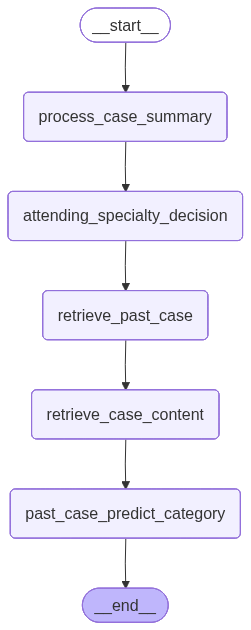

In [21]:
print("Initializing past case only triage pipeline...")
past_case_only_triage_graph = build_past_case_only_triage_graph(
    summary_vectordb=summary_vectordb, 
    case_json_dir=case_json_dir
)
print("Past case only pipeline ready!")

past_case_only_triage_graph

## Step 4: Evaluation Framework


The following sections implement a testing framework to evaluate the system's performance on real emergency cases. This enables:
1. Validating the quality of guideline retrieval
2. Assessing the relevance of retrieved similar cases
3. Analyzing the accuracy and reasoning of final triage assessments

## Single Case Testing

This function allows testing the system on individual cases to examine the detailed processing steps and outputs.`

In [22]:
def process_case_file_past_case_only(file_path: str) -> Dict[str, Any]:
    """
    Process a case file using the past case only triage pipeline.
    
    Args:
        file_path (str): Path to the case file (json)
        
    Returns:
        Dict[str, Any]: Complete state from the past case only triage graph execution
    """
    case_data = load_case_from_json(file_path)
    
    print("Case Content:")
    print(f"Age: {case_data.get('Demographics', {}).get('Age', 'Unknown')}")
    print(f"Sex: {case_data.get('Demographics', {}).get('Sex', 'Unknown')}")
    print(f"Chief Complaint: {case_data.get('Clinical Presentation', {}).get('Chief complaint', 'Unknown')[:100]}...")
    print("-" * 80)
    
    initial_state = GraphState(
        case_json_full=case_data,
        specialty_list=AGENT_SPECIALTY_LIST,
    )

    return past_case_only_triage_graph.invoke(
        initial_state,
        config={"retrieve_case_content": {"case_json_dir": case_json_dir}}
    )

In [23]:
# process_case_file_past_case_only(file_path="PATH_TO_TEST_JSON")

## Batch Evaluation

This section implements a framework for processing multiple cases and saving the results for systematic evaluation. The outputs include:
1. Case summaries
2. Similar past cases
3. Complete triage assessments with reasoning

These structured outputs can be analyzed to evaluate the system's performance across different case types and triage categories.

In [24]:
def batch_process_directory(
    input_directory: str,
    output_directory: str,
    max_files: int = None,
    verbose: bool = True
) -> int:
    """
    Process all JSON files using the past case only pipeline and save results.
    """
    os.makedirs(output_directory, exist_ok=True)
    
    json_files = []
    for root, _, files in os.walk(input_directory):
        for file in files:
            if file.endswith('.json'):
                json_files.append(os.path.join(root, file))
    
    if max_files:
        json_files = json_files[:max_files]
    
    print(f"Found {len(json_files)} JSON files to process with past case only pipeline")
    
    processed_count = 0
    skipped_count = 0
    error_count = 0
    
    for file_path in tqdm(json_files, desc="Processing cases (past case only)"):
        try:
            rel_path = os.path.relpath(file_path, input_directory)
            file_name = os.path.basename(file_path)
            base_name = os.path.splitext(file_name)[0]
            
            rel_dir = os.path.dirname(rel_path)
            output_subdir = os.path.join(output_directory, rel_dir)
            os.makedirs(output_subdir, exist_ok=True)
            
            output_file_path = os.path.join(output_subdir, f"{base_name}_pastcase_only_output.json")
            if os.path.exists(output_file_path):
                if verbose:
                    print(f"\nSkipping {rel_path} - past case only output file already exists")
                skipped_count += 1
                continue
            
            if verbose:
                print(f"\nProcessing: {rel_path}")
            
            state = process_case_file_past_case_only(file_path)
            
            output_data = {
                "summary_text": state.get("summary_text"),
                "case_json_full": state.get("case_json_full"),
                "retrieved_cases_simplified": [
                    {
                        "doc_id": case.get("doc_id"),
                        "similarity_score": case.get("similarity_score"),
                        "content": case.get("content")
                    } 
                    for case in state.get("retrieved_cases_content", [])
                ],
                "past_cases_count": len(state.get("retrieved_cases_content", [])),
                "final_assessment": state.get("final_assessment"),
                "final_category": state.get("final_category"),
                "final_confidence": state.get("final_confidence"),
                "processing_failed": state.get("processing_failed", False),
                "failure_reason": state.get("failure_reason"),
                "pipeline_info": {
                    "guidelines_used": False,
                    "max_past_cases": k_cases,
                    "similarity_threshold": 0.7,
                    "reasoning_steps": 2
                }
            }
            
            with open(output_file_path, 'w', encoding='utf-8') as f:
                json.dump(output_data, f, indent=2, ensure_ascii=False)
            
            processed_count += 1
            
            if verbose:
                print(f"Saved output to: {output_file_path}")
                print(f"Past cases retrieved: {len(state.get('retrieved_cases_content', []))}")
        
        except Exception as e:
            print(f"Error processing {file_path}: {str(e)}")
            print(traceback.format_exc())
            error_count += 1
    
    print("\nPast Case Only Processing Complete")
    print(f"Total files found: {len(json_files)}")
    print(f"Files processed: {processed_count}")
    print(f"Files skipped (already exist): {skipped_count}")
    print(f"Files with errors: {error_count}")
    
    return processed_count

In [25]:
batch_process_directory(
    input_directory = r"C:\Users\Thomas Wong\Documents\ML\project\RAG_paper\MECR-RAG-Clinical-Research\data\input",
    output_directory = r"C:\Users\Thomas Wong\Documents\ML\project\RAG_paper\MECR-RAG-Clinical-Research\data\output",
    max_files = None,
    verbose = True
)

Found 2 JSON files to process with past case only pipeline


Processing cases (past case only):   0%|          | 0/2 [00:00<?, ?it/s]


Processing: PhA3_486.json
Case Content:
Age: 80 years
Sex: F
Chief Complaint: H3 patient , feeling dizziness and palpitation in pharmacy at 12:00. patinet then back to H3, Found ...
--------------------------------------------------------------------------------


C:\Users\Thomas Wong\AppData\Local\Temp\ipykernel_18232\3240914004.py:7: PydanticDeprecatedSince20: `min_items` is deprecated and will be removed, use `min_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  specialties: List[SpecialtyLiteral] = Field(
C:\Users\Thomas Wong\AppData\Local\Temp\ipykernel_18232\3240914004.py:7: PydanticDeprecatedSince20: `max_items` is deprecated and will be removed, use `max_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  specialties: List[SpecialtyLiteral] = Field(


Primary Specialty: Medicine
Explanation: An 80-year-old patient presenting with dizziness, palpitations, hypotension, and chest discomfort most likely has a cardiac or general medical etiology (e.g., arrhythmia, acute coronary syndrome, vasovagal episode, or sepsis). These fall under the broad scope of internal medicine, which can manage the initial workup and coordinate further subspecialty input if needed.
Base metadata filters: {'age_group': 'Adult'}
Using primary specialty: Medicine (raw values: ['Medicine', 'IDU'])
Unique specialty values for filtering: ['IDU', 'Medicine']
Applying filters with specialty value 'IDU': {'age_group': 'Adult', 'Attending Specialty': 'IDU'}
Found 1 cases with specialty 'IDU'
Applying filters with specialty value 'Medicine': {'age_group': 'Adult', 'Attending Specialty': 'Medicine'}
Found 1410 cases with specialty 'Medicine'
Found 1411 unique cases after filtering
========= Retrieved 5 high-quality past cases (similarity >= 0.7) ===============
Found 5 c

2